In [52]:
import sys
if "vision_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [53]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import cv2

print("opencv:", cv2.__version__)
print("numpy:", np.__version__)

opencv: 4.13.0
numpy: 2.2.5


<font color = #000000 >

## 7. 图像金字塔与轮廓检测
</font>


In [54]:
picture = '../Pictures/'
# 定义图像展示函数
def img_show(img):
    if img is None:
        print("图像读取失败")
    else:
        # 图像展示
        cv2.imshow("image", img)    # 首先需要确定图像存在才能打开
        print("img.shape = " , img.shape)
        cv2.waitKey(0)  # 等待时间,0对应无限等待,知道按下任意按键
        cv2.destroyAllWindows() 

<font color = #000000>

### 7-1 轮廓检测方法:findContours
#### <font color = #ef0404>函数 cv2.findContours(img,mode,method) </font>
mode:轮廓检索模式
- RETR_EXTERNAL ：只检索最外面的轮廓；
- RETR_LIST：检索所有的轮廓，并将其保存到一条链表当中；
- RETR_CCOMP：检索所有的轮廓，并将他们组织为两层：顶层是各部分的外部边界，第二层是空洞的边界;
- **RETR_TREE**：检索所有的轮廓，并重构嵌套轮廓的整个层次,这个最重要,一般使用这个就行了

method:轮廓逼近方法
- CHAIN_APPROX_NONE ：以Freeman链码的方式输出轮廓，所有其他方法输出多边形（顶点的序列）。
- CHAIN_APPROX_SIMPLE :压缩水平的、垂直的和斜的部分，也就是，函数只保留他们的终点部分。


| `返回值`         | 类型      | 含义        |
| ----------- | ------- | --------- |
| `contours`  | list    | 所有轮廓的点集合  |
| `hierarchy` | numpy数组 | 轮廓之间的层级关系 |


#### 模块绘制

+ 绘制的背景必须彩色，“图像必须是三通道”才能显示彩色轮廓,如果是二值或者灰度,那么绘出的线就是黑白的,根本看不到
+ 绘制的背景如果采用原图,必须copy,不然原图会被破坏

</font>

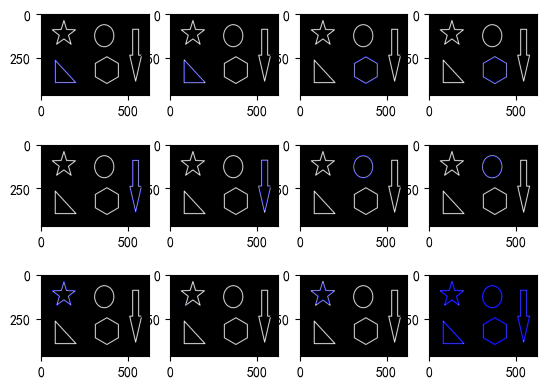

In [55]:
# 轮廓检测
# 1. 读图,得到二值化处理后的图像

img = cv2.imread(picture + "contours.png")
gray = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)  # 意思是大于127就是255,小于127就是0
# 2. 绘制图像

# ret = np.hstack((gray , thresh))
# img_show(ret)

# plt.subplot(231) , plt.imshow(img    , cmap="gray") , plt.title('原图')
# plt.subplot(232) , plt.imshow(thresh , cmap="gray") , plt.title('二值化后图')

# 3. 轮廓检测
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

# 4. 观察所有轮廓捕获的contours
# drawContours的contourIdx表示需要绘出的contours集的子集id,给-1就是全绘
for i in range(len(contours)):
    plt.subplot(3,4,i+1)    # !!!原图需要copy!!!,否则就是直接在原图上作画,影响后续实验
    plt.imshow(cv2.drawContours(img.copy(), contours,  i , (0, 0, 255), 2))
plt.subplot(3,4,len(contours) + 1) 
plt.imshow(cv2.drawContours(img.copy(), contours, -1, (0, 0, 255), 2))


<font color = #000000>

### 7-2 模版匹配

+ 其实就是从一整张Template模版图找出一个拼图与参考图最匹配(参考图就是从Template模版图拿出来的)
---
+ 模板匹配函数
    + cv2.matchTemplate()
    + result = cv2.matchTemplate(image, template, method)
        + image 原图
        + template 模板
        + method 匹配方法

+ method 匹配方法

| 方法               | 含义      |
| ---------------- | ------- |
| TM_SQDIFF        | 平方差     |
| TM_SQDIFF_NORMED | 归一化平方差  |
| TM_CCORR         | 相关匹配    |
| TM_CCORR_NORMED  | 归一化相关   |
| TM_CCOEFF        | 相关系数    |
| TM_CCOEFF_NORMED | 归一化相关系数 |

TM_SQDIFF_NORMED最常用,-1~1的范围,越接近1越相似

---

+ 返回值
    + result = 相似度矩阵
    + 大小: (W-w+1 , H-h+1) (其中W和H为原图的shape , wh为模版图的shape)
---
+ 寻找最佳匹配位置
    + min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

| 变量      | 含义    |
| ------- | ----- |
| min_val | 最小相似度 |
| max_val | 最大相似度 |
| min_loc | 最小值位置 |
| max_loc | 最大值位置 |

</font>

In [56]:
def cat_two(img1, img2):
    h = min(img1.shape[0], img2.shape[0])

    img1 = cv2.resize(img1, (int(img1.shape[1]*h/img1.shape[0]), h))
    img2 = cv2.resize(img2, (int(img2.shape[1]*h/img2.shape[0]), h))

    return np.hstack((img1, img2))

In [57]:
# 1. 读取模版图和原图
Template = cv2.imread(picture + 'lena.jpg')  # 模版图片
img = cv2.imread(picture + 'lena_part.png')  # 待匹配图片
# 2. 展示图片
# ret = cat_two(Template ,img)
# img_show(ret)
# 3. 打印尺寸
print(img.shape)
print(Template.shape)
# 4. 模版匹配
result = cv2.matchTemplate(img , Template , cv2.TM_SQDIFF_NORMED)
print(result.shape)
# 5. 寻找位置
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
print(min_val, max_val, min_loc, max_loc)
# 6. 接着绘制出来即可

(300, 270, 3)
(263, 263, 3)
(38, 8)
0.21545766294002533 0.2194717675447464 (0, 28) (7, 37)


<font color = #000000>

### 7-3 图像金字塔:上采样/下采样
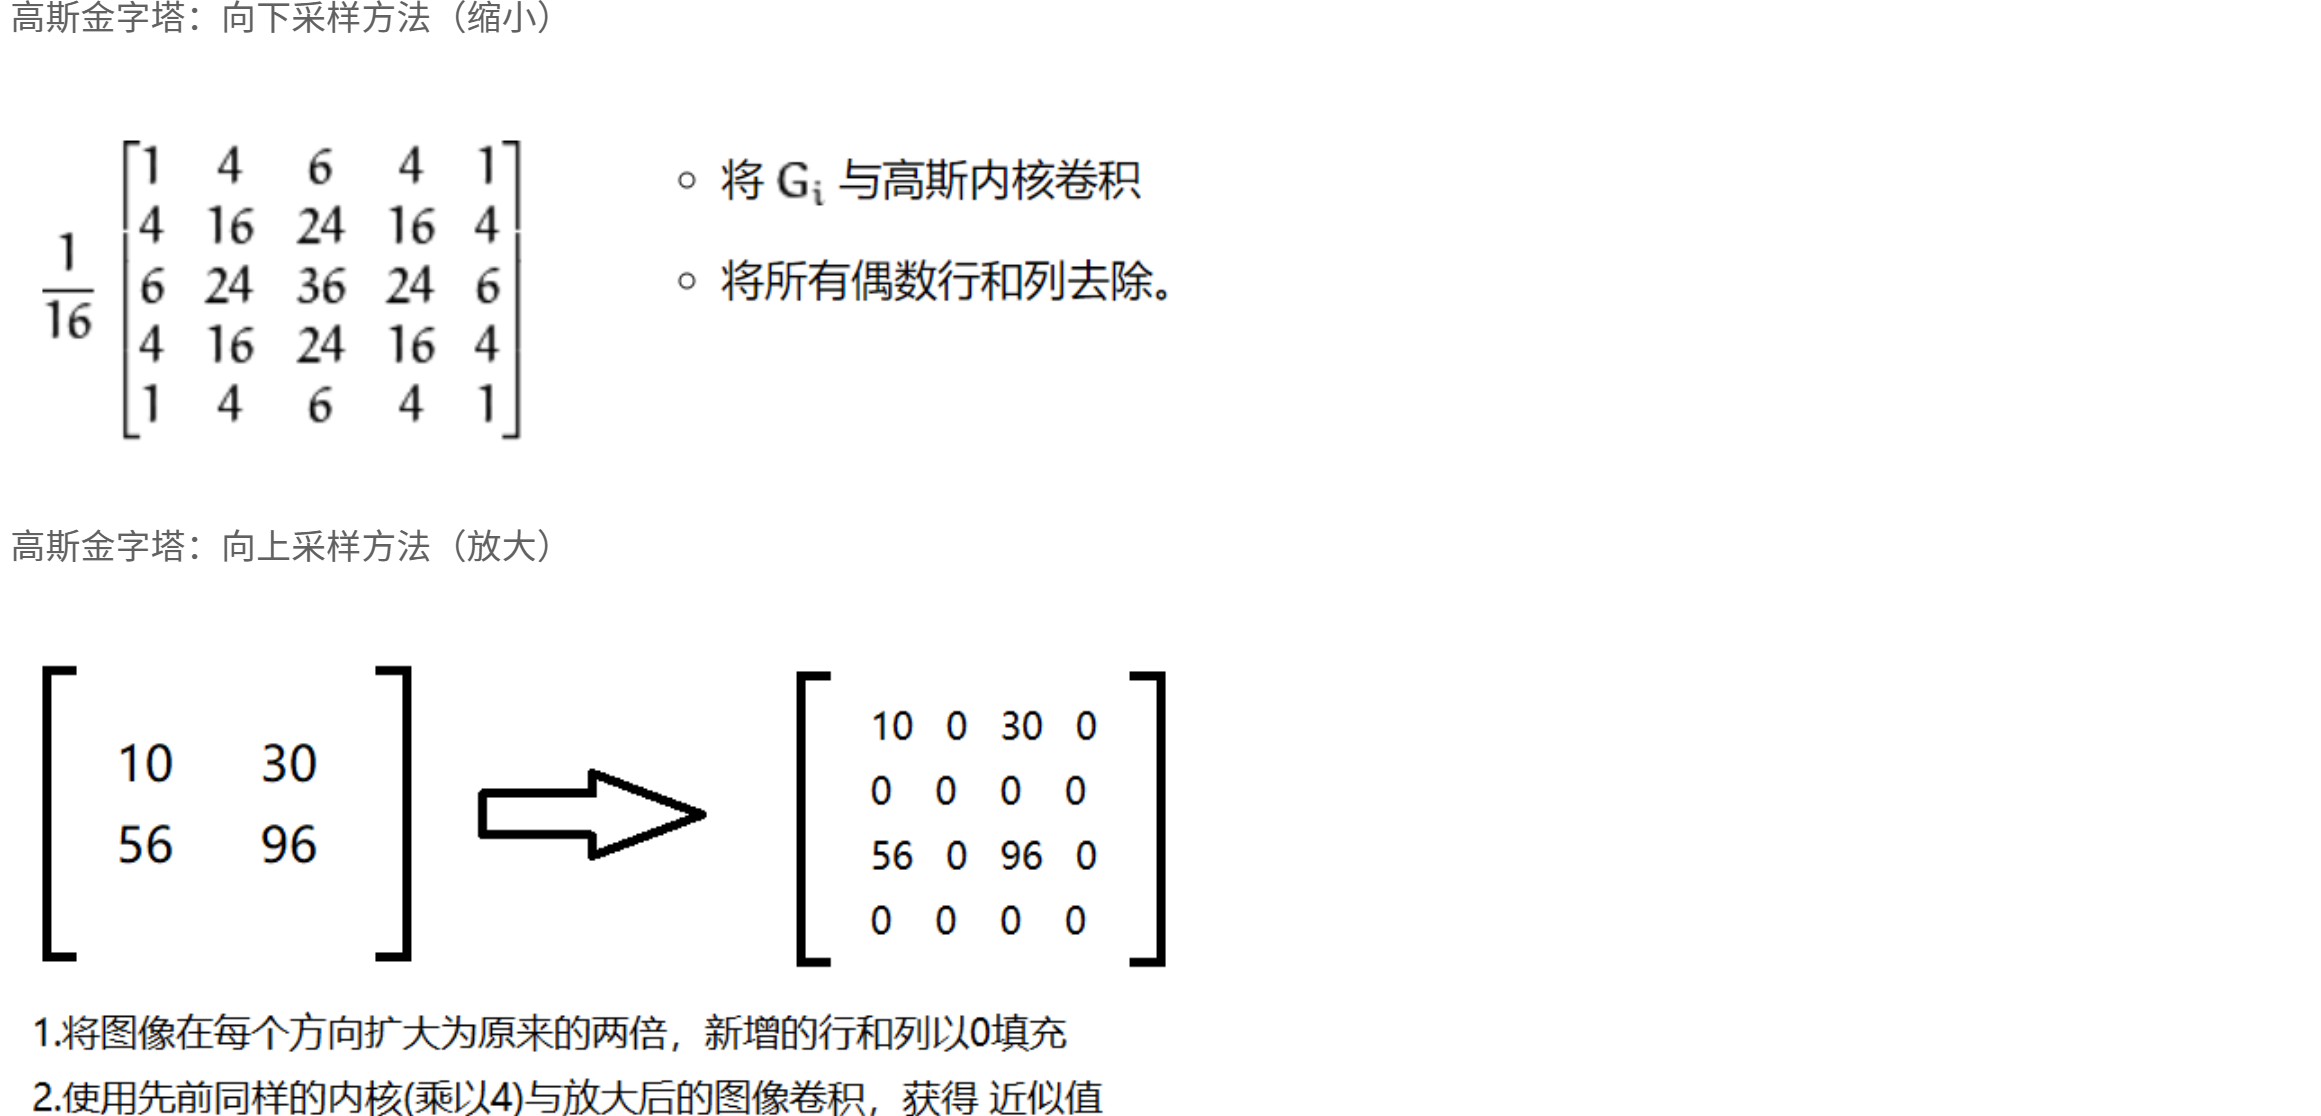


</font>

(442, 340, 3)


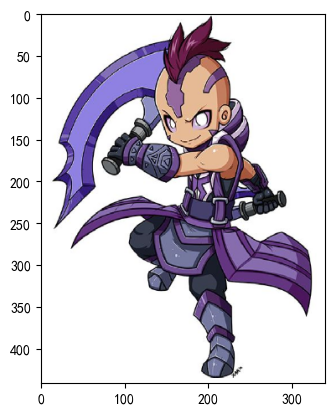

In [58]:
# 读取图像
img = cv2.imread(picture + 'AM.png' , cv2.IMREAD_COLOR_RGB)
plt.imshow(img)
print(img.shape)

(884, 680, 3)


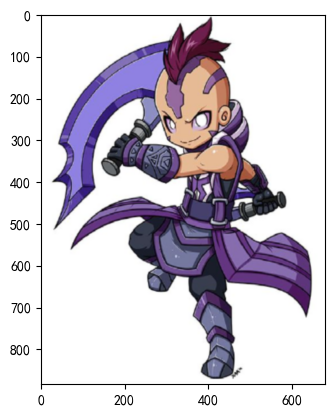

In [59]:
# 上采样,shape扩大成了2倍
up = cv2.pyrUp(img)
plt.imshow(up) 
print(up.shape)

(221, 170, 3)


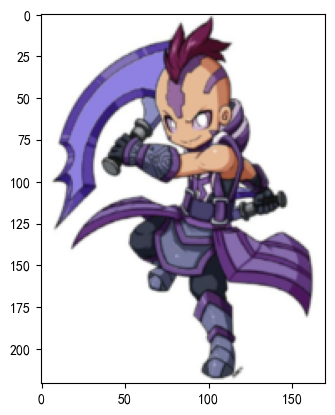

In [60]:
# 下采样,shape变成原来的1/4
down = cv2.pyrDown(img)
plt.imshow(down) 
print(down.shape)

<font color = #000000>

### 7-4 拉普拉斯金字塔
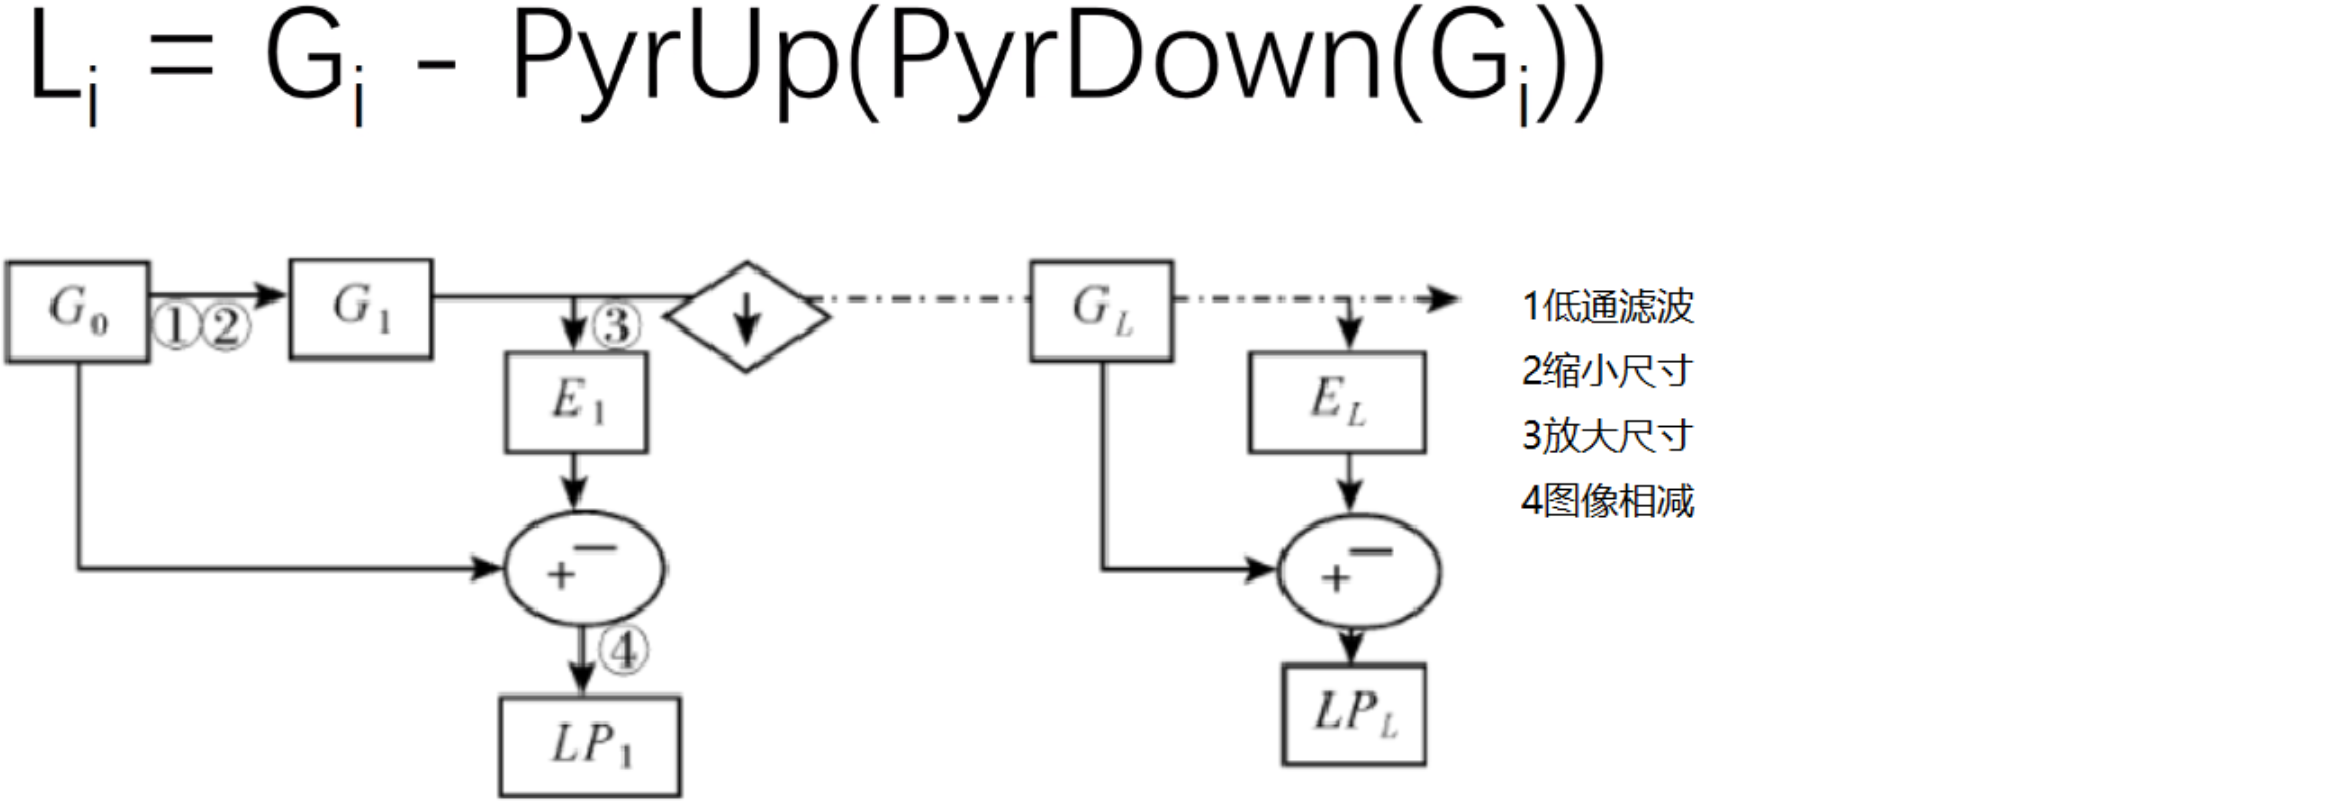


</font>

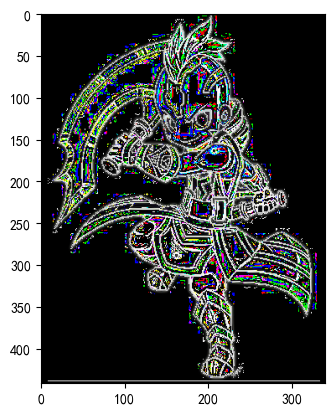

In [61]:
# Laplace
down=cv2.pyrDown(img)
down_up=cv2.pyrUp(down)
l_1=img-down_up
plt.imshow(l_1)

<font color = #000000>

### 7-5 轮廓检测结果




</font>

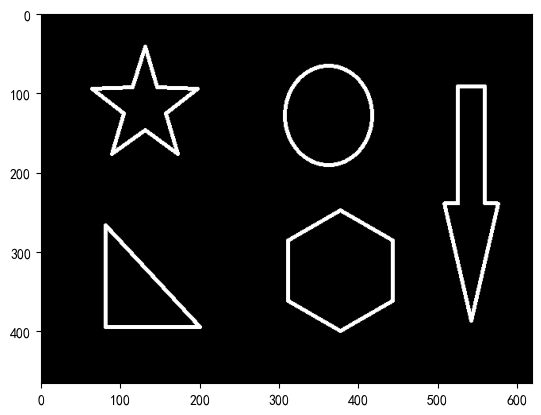

In [62]:
# 先读取图像
img = cv2.imread(picture + 'contours.png')
# 灰度
gray = cv2.cvtColor(img , cv2.COLOR_RGB2GRAY)
# 灰度图转二值化(只有0和255)
ret , thresh = cv2.threshold(gray , 127 , 255 , cv2.THRESH_BINARY)
# 展示图像
plt.imshow(thresh , cmap='gray')

In [63]:
# 轮廓检测
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

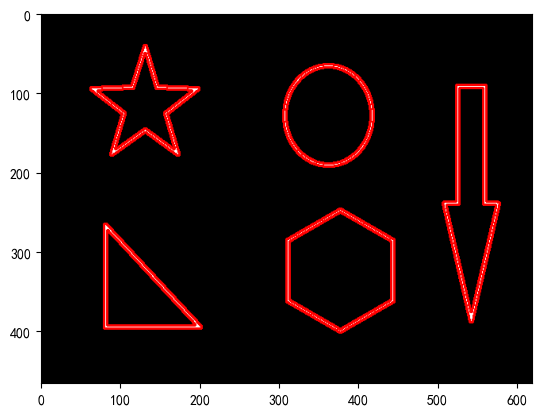

In [64]:
# 轮廓绘制
draw_img = img.copy()   # 必须copy!
res = cv2.drawContours(draw_img , contours , -1 , (255, 0, 0) , 2)  # RGB,所以是R: 255
plt.imshow(res , cmap='gray')

In [65]:
# 轮廓特征
cnt = contours[0]
# 面积
print( cv2.contourArea(cnt) )
# 周长,True表示闭合的
print( cv2.arcLength(cnt , True))

8500.5
437.9482651948929


<font color = #000000>

####  轮廓近似



</font>

(<Axes: title={'center': '第1个轮廓的近似'}>,
 Text(0.5, 1.0, '第1个轮廓的近似'))

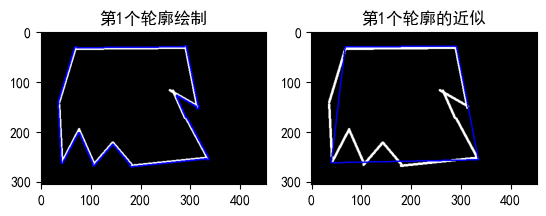

In [66]:
# 轮廓近似
img = cv2.imread(picture + 'contours2.png')

# 转为灰度图
gray = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
# 进行二值化
_ , thresh = cv2.threshold(gray , 127 , 255 , cv2.THRESH_BINARY)    # 不关心第1个返回值阈值
# 寻找轮廓
contours , _ = cv2.findContours(thresh , cv2.RETR_TREE , cv2.CHAIN_APPROX_NONE) # 不关心 _ 层级关系
# 拿取第1个轮廓
cnt = contours[0]
# 轮廓绘制
draw_img = img.copy() 
res = cv2.drawContours(draw_img , [cnt] , -1 , (0,0,255) , 2) # BGR
plt.subplot(121) , plt.imshow(res , 'gray') , plt.title('第1个轮廓绘制')

# !!!轮廓近似!!!
# 核心思想:去斜留直,自己配置阈值来表明去斜留直的强度
epsilon = 0.1 * cv2.arcLength(cnt , True)
approx  = cv2.approxPolyDP(cnt , epsilon , True)

# 轮廓绘制到原图的复印件上面,一定要记得单个参数需要[]
draw_img = img.copy()
res = cv2.drawContours(draw_img , [approx] , -1 , (0,0,255) , 2)
plt.subplot(122) , plt.imshow(res , 'gray') , plt.title('第1个轮廓的近似')


(<Axes: title={'center': '0.1系数'}>,
 Text(0.5, 1.0, '0.1系数'))

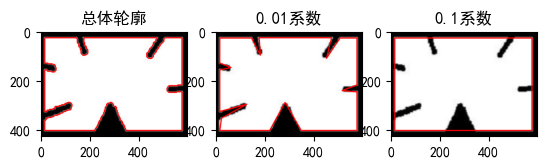

In [67]:
# 案例2
# 读取图像
img = cv2.imread(picture + 'contours4.png' , cv2.IMREAD_GRAYSCALE)
# 轮廓检测
_ , thresh = cv2.threshold(img , 217 , 255 , cv2.THRESH_BINARY) # 必须要二值化,这样才能检测的更加准确
contours , _ =  cv2.findContours(thresh , cv2.RETR_TREE , cv2.CHAIN_APPROX_NONE)
# 绘制轮廓
img_RGB = cv2.cvtColor(img , cv2.COLOR_GRAY2RGB)
res = cv2.drawContours(img_RGB , contours , 0 , (255,0,0) , 3)
plt.subplot(131) , plt.imshow(res , 'gray') , plt.title('总体轮廓')
# 轮廓近似
epsilon  = 0.01 * cv2.arcLength(contours[0] , True)
epsilon2 = 0.1  * cv2.arcLength(contours[0] , True)
approx   = cv2.approxPolyDP(contours[0] , epsilon , True)
approx2  = cv2.approxPolyDP(contours[0] , epsilon2 , True)
# 绘制轮廓近似
draw_img = cv2.cvtColor(img , cv2.COLOR_GRAY2RGB)
res  = cv2.drawContours(draw_img.copy() , [approx ] , -1 , (255,0,0) , 3)
res2 = cv2.drawContours(draw_img.copy() , [approx2] , -1 , (255,0,0) , 3)
plt.subplot(132) , plt.imshow(res  , 'gray') , plt.title('0.01系数')
plt.subplot(133) , plt.imshow(res2 , 'gray') , plt.title('0.1系数')

<font color = #000000>

#### 边界矩形



</font>

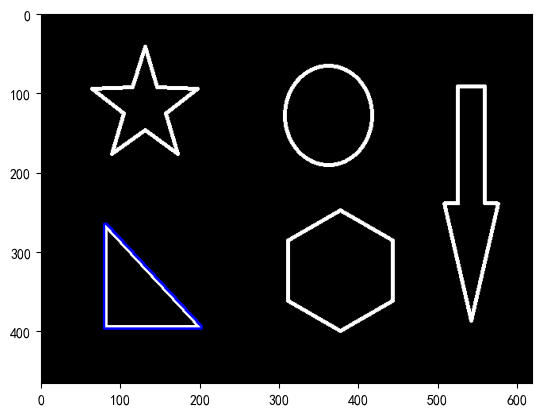

In [68]:
img = cv2.imread(picture + 'contours.png' , cv2.IMREAD_GRAYSCALE)
# 二值化
_ , thresh = cv2.threshold(img , 127 , 255  , cv2.THRESH_BINARY)
# 轮廓检测
contours , _ = cv2.findContours(thresh , cv2.RETR_TREE , cv2.CHAIN_APPROX_NONE)
# 轮廓绘制:需要将背景颜色配置为彩色
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
ret = cv2.drawContours(img_color , contours , 0 , (0,0,255) , 2)
plt.imshow(ret , 'gray')

轮廓面积与边界矩形面积比 =  0.5154317244724715


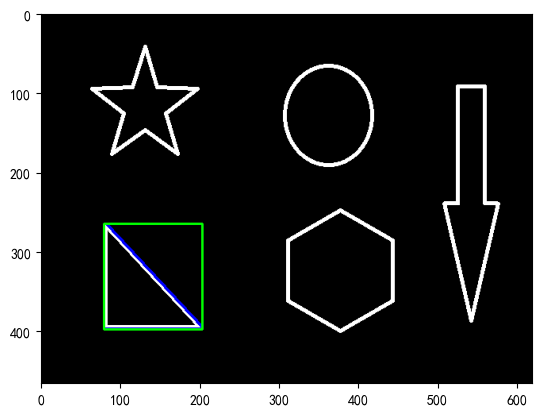

In [69]:
# 选择一个需要检测矩形的轮廓
cnt = contours[0] # 三角形
# 调用函数
x, y , w , h = cv2.boundingRect(cnt)
# 计算面积
area = cv2.contourArea(cnt)
rect_area = w * h
# 轮廓面积与边界矩形面积比
print('轮廓面积与边界矩形面积比 = ' , float(area) / rect_area)
# 绘制轮廓
img = cv2.rectangle(img_color, (x,y) , (x+w , y+h) , (0,255,0) , 2)
plt.imshow(img , 'gray')

<font color = #000000>

### 7-3 



</font>